In [2]:
import pandas as pd
import warnings as ws

ws.filterwarnings('ignore')
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

independent = dataset[['User ID', 'Age', 'EstimatedSalary', 'Gender_Male']]
dependent = dataset['Purchased'] 

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0
)

print(dataset['Purchased'].value_counts())

Purchased
0    257
1    143
Name: count, dtype: int64


In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train)

print("Before SMOTE:", Y_train.value_counts().to_dict())
print("After Y_train  SMOTE:", pd.Series(Y_train_sm).value_counts())

# Train model
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_sm, Y_train_sm)

Y_pred = classifier.predict(X_test)

# Evaluation
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))



Before SMOTE: {0: 178, 1: 102}
After Y_train  SMOTE: Purchased
0    178
1    178
Name: count, dtype: int64

Confusion Matrix:
[[72  7]
 [ 4 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        79
           1       0.84      0.90      0.87        41

    accuracy                           0.91       120
   macro avg       0.89      0.91      0.90       120
weighted avg       0.91      0.91      0.91       120




ROC-AUC Score: 0.9548


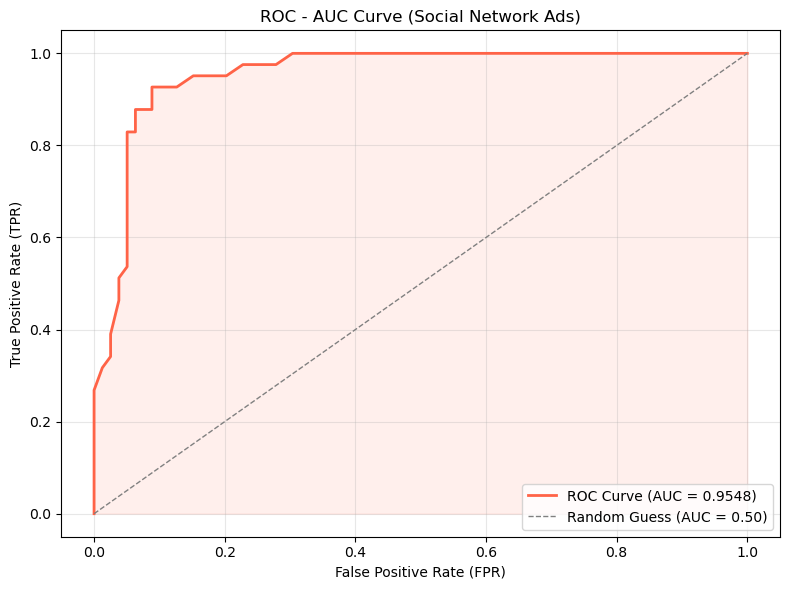

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Step 1 — Get probability scores for class 1 (Purchased)
Y_pred_proba = classifier.predict_proba(X_test)[:, 1]

# Step 2 — Calculate AUC score
auc_score = roc_auc_score(Y_test, Y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# Step 3 — Get FPR and TPR values for plotting
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

# Step 4 — Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='tomato', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Guess (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC - AUC Curve (Social Network Ads)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()